# MNIST Image Denoising using Autoencoders

## Importing required packages

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [2]:
transforms=transforms.ToTensor()

## Downloading requried data

In [3]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

## Defining dataloaders

In [4]:
valid_size=0.2

# IMPORTANT 
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

In [5]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [6]:
# checking our data
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(images.shape)
print(labels.shape)

torch.Size([20, 1, 28, 28])
torch.Size([20])


## Visualizing a Training batch

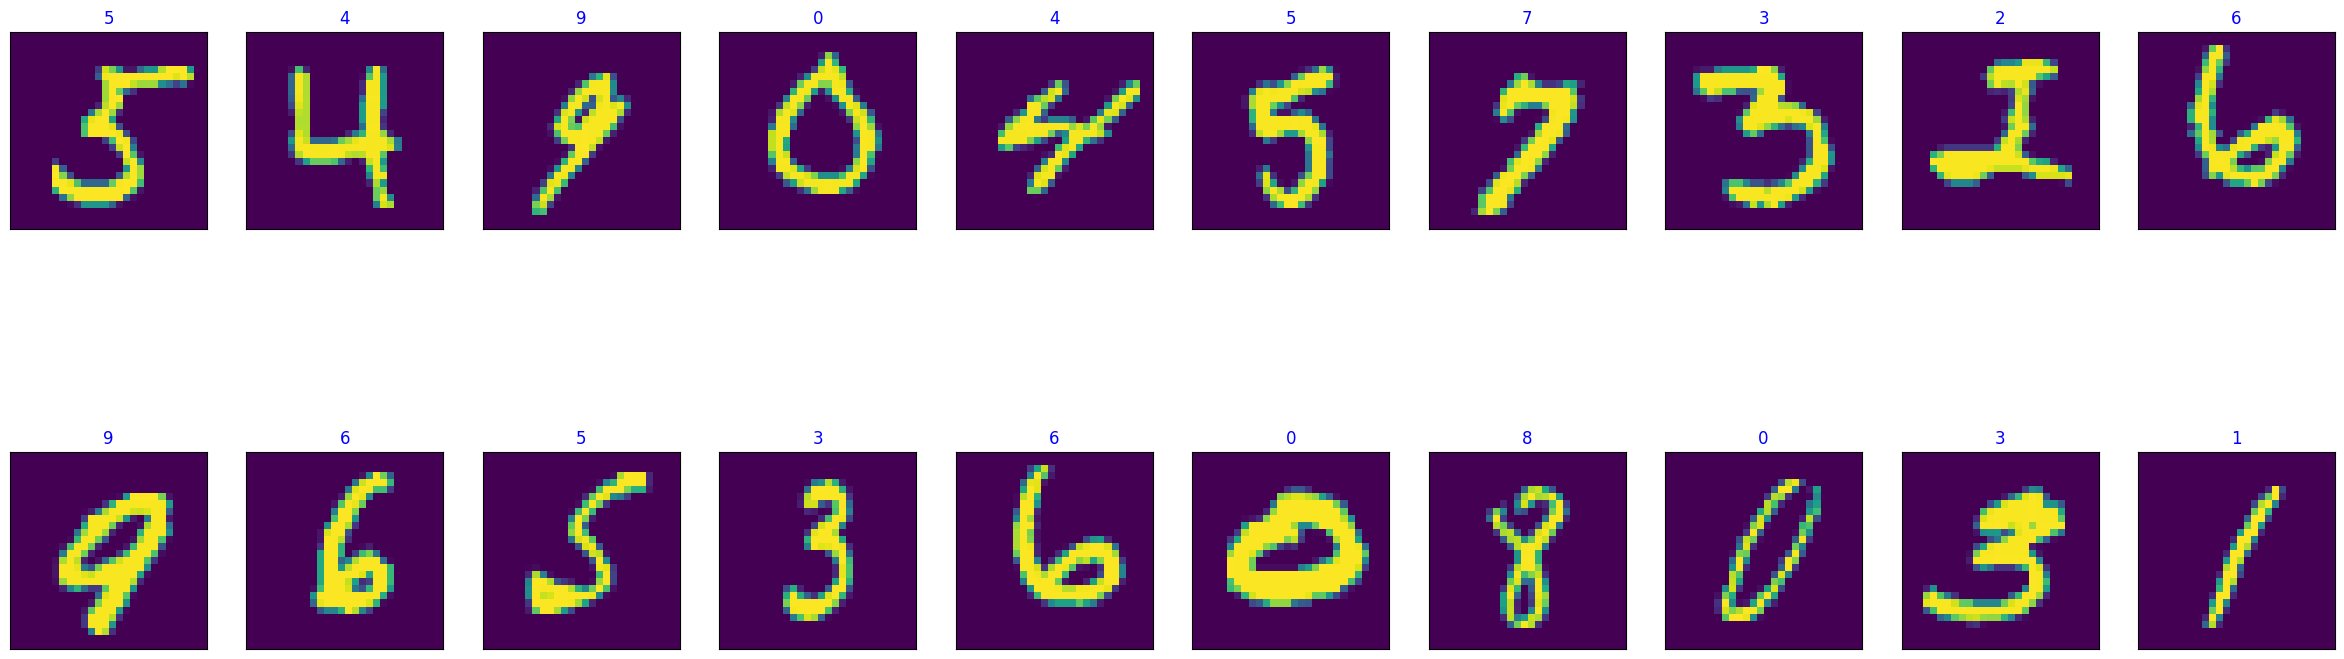

In [7]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Defining Architecture

In [8]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)
    
    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [9]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

In [10]:
def add_noise(images, noise_factor=0.6):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

## Defining our Loss Function

In [11]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [12]:
def trainNet(model, lr, state='fully'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Number of epochs
    loss_keeper = {'train': [], 'valid': []}
    epochs = 20

    # Initialize minimum validation loss
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0

        # =========================
        # TRAINING PHASE
        # =========================
        model.train()

        for images, _ in train_loader:

            if use_cuda and torch.cuda.is_available():
                images = images.cuda()

            clean_images = images
            noisy_images = add_noise(clean_images)

            if state == 'fully':
                noisy_images = noisy_images.view(noisy_images.size(0), -1)
                clean_images = clean_images.view(clean_images.size(0), -1)

            optimizer.zero_grad()

            output = model(noisy_images)

            loss = criterion(output, clean_images)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        # =========================
        # VALIDATION PHASE
        # =========================
        model.eval()

        with torch.no_grad():
            for images, _ in valid_loader:

                if use_cuda and torch.cuda.is_available():
                    images = images.cuda()

                clean_images = images
                noisy_images = add_noise(clean_images)

                if state == 'fully':
                    noisy_images = noisy_images.view(noisy_images.size(0), -1)
                    clean_images = clean_images.view(clean_images.size(0), -1)

                output = model(noisy_images)

                loss = criterion(output, clean_images)

                valid_loss += loss.item()

        # Average losses
        train_loss = train_loss / len(train_loader)
        valid_loss = valid_loss / len(valid_loader)

        # Save losses
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss:.6f}\tValidation Loss : {valid_loss:.6f}")

        if valid_loss <= valid_loss_min:
            print(f"Validation loss decreased from {valid_loss_min:.6f} --> {valid_loss:.6f}. Saving Model...")
            z = type(model).__name__
            torch.save(model.state_dict(), z + '_model.pth')
            valid_loss_min = valid_loss

    return loss_keeper

In [13]:
m1_loss=trainNet(model_1,0.001)


Epoch : 1	Training Loss : 0.053389	Validation Loss : 0.039594
Validation loss decreased from inf --> 0.039594. Saving Model...

Epoch : 2	Training Loss : 0.037425	Validation Loss : 0.036387
Validation loss decreased from 0.039594 --> 0.036387. Saving Model...

Epoch : 3	Training Loss : 0.035673	Validation Loss : 0.035450
Validation loss decreased from 0.036387 --> 0.035450. Saving Model...

Epoch : 4	Training Loss : 0.035259	Validation Loss : 0.035338
Validation loss decreased from 0.035450 --> 0.035338. Saving Model...

Epoch : 5	Training Loss : 0.035028	Validation Loss : 0.035094
Validation loss decreased from 0.035338 --> 0.035094. Saving Model...

Epoch : 6	Training Loss : 0.034836	Validation Loss : 0.034930
Validation loss decreased from 0.035094 --> 0.034930. Saving Model...

Epoch : 7	Training Loss : 0.034693	Validation Loss : 0.034721
Validation loss decreased from 0.034930 --> 0.034721. Saving Model...

Epoch : 8	Training Loss : 0.034574	Validation Loss : 0.034922

Epoch : 9	

In [14]:
m2_loss=trainNet(model_2,0.001,'conv')


Epoch : 1	Training Loss : 0.052574	Validation Loss : 0.037709
Validation loss decreased from inf --> 0.037709. Saving Model...

Epoch : 2	Training Loss : 0.036322	Validation Loss : 0.033965
Validation loss decreased from 0.037709 --> 0.033965. Saving Model...

Epoch : 3	Training Loss : 0.033057	Validation Loss : 0.032651
Validation loss decreased from 0.033965 --> 0.032651. Saving Model...

Epoch : 4	Training Loss : 0.032242	Validation Loss : 0.032131
Validation loss decreased from 0.032651 --> 0.032131. Saving Model...

Epoch : 5	Training Loss : 0.031637	Validation Loss : 0.031406
Validation loss decreased from 0.032131 --> 0.031406. Saving Model...

Epoch : 6	Training Loss : 0.030890	Validation Loss : 0.030503
Validation loss decreased from 0.031406 --> 0.030503. Saving Model...

Epoch : 7	Training Loss : 0.030187	Validation Loss : 0.029932
Validation loss decreased from 0.030503 --> 0.029932. Saving Model...

Epoch : 8	Training Loss : 0.029695	Validation Loss : 0.029568
Validation 

In [15]:
m3_loss=trainNet(model_3,0.001,'conv')

/var/folders/98/g26wy2d54m727kzzxfvlss340000gn/T/ipykernel_4319/219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/var/folders/98/g26wy2d54m727kzzxfvlss340000gn/T/ipykernel_4319/219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.036012	Validation Loss : 0.027165
Validation loss decreased from inf --> 0.027165. Saving Model...

Epoch : 2	Training Loss : 0.025624	Validation Loss : 0.024615
Validation loss decreased from 0.027165 --> 0.024615. Saving Model...

Epoch : 3	Training Loss : 0.023648	Validation Loss : 0.022721
Validation loss decreased from 0.024615 --> 0.022721. Saving Model...

Epoch : 4	Training Loss : 0.022077	Validation Loss : 0.021745
Validation loss decreased from 0.022721 --> 0.021745. Saving Model...

Epoch : 5	Training Loss : 0.021553	Validation Loss : 0.021451
Validation loss decreased from 0.021745 --> 0.021451. Saving Model...

Epoch : 6	Training Loss : 0.021271	Validation Loss : 0.021281
Validation loss decreased from 0.021451 --> 0.021281. Saving Model...

Epoch : 7	Training Loss : 0.021101	Validation Loss : 0.021072
Validation loss decreased from 0.021281 --> 0.021072. Saving Model...

Epoch : 8	Training Loss : 0.020939	Validation Loss : 0.020912
Validation 

In [16]:
#model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth'))
#model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth'))
#model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth'))

In [17]:
# Save the trained denoising models

torch.save(model_1.state_dict(), "denoising_ffnn.pth")
torch.save(model_2.state_dict(), "denoising_transposecnn.pth")
torch.save(model_3.state_dict(), "denoising_upsamplecnn.pth")

print("Models saved successfully!")

Models saved successfully!


## Plotting Loss

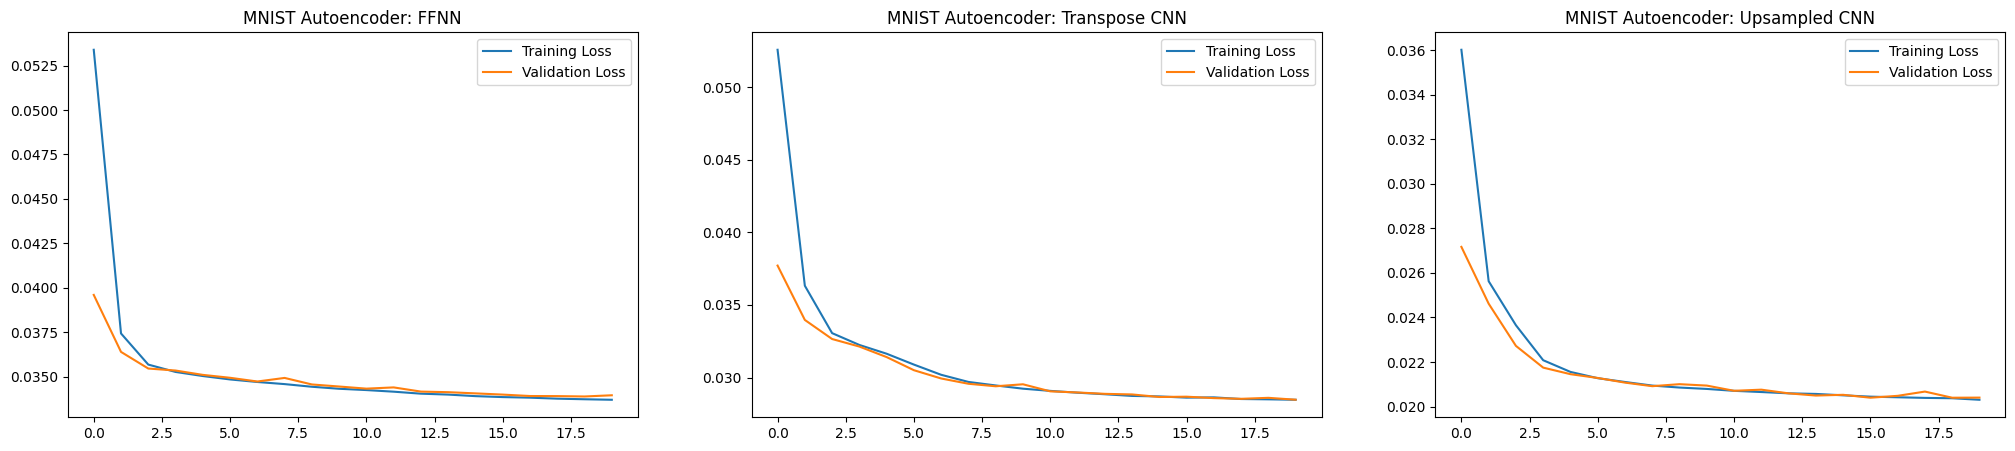

In [18]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [19]:
def test(model, state='fully'):

    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    if use_cuda and torch.cuda.is_available():
        images = images.cuda()

    clean = images
    noisy = add_noise(clean)

    if state == 'fully':
        noisy_input = noisy.view(noisy.size(0), -1)
    else:
        noisy_input = noisy

    output = model(noisy_input)

    if state == 'fully':
       output = output.view(images.size(0), 1, 28, 28)

    clean = clean.cpu().numpy()
    noisy = noisy.cpu().numpy()
    output = output.detach().cpu().numpy()

    fig, axes = plt.subplots(3, 10, figsize=(20, 6))

    for i in range(min(10, len(clean))):
        axes[0, i].imshow(clean[i].squeeze(), cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis("off")

        axes[1, i].imshow(noisy[i].squeeze(), cmap='gray')
        axes[1, i].set_title("Noisy")
        axes[1, i].axis("off")

        axes[2, i].imshow(output[i].squeeze(), cmap='gray')
        axes[2, i].set_title("Denoised")
        axes[2, i].axis("off")

    plt.show()

## FFNN Autoencoder

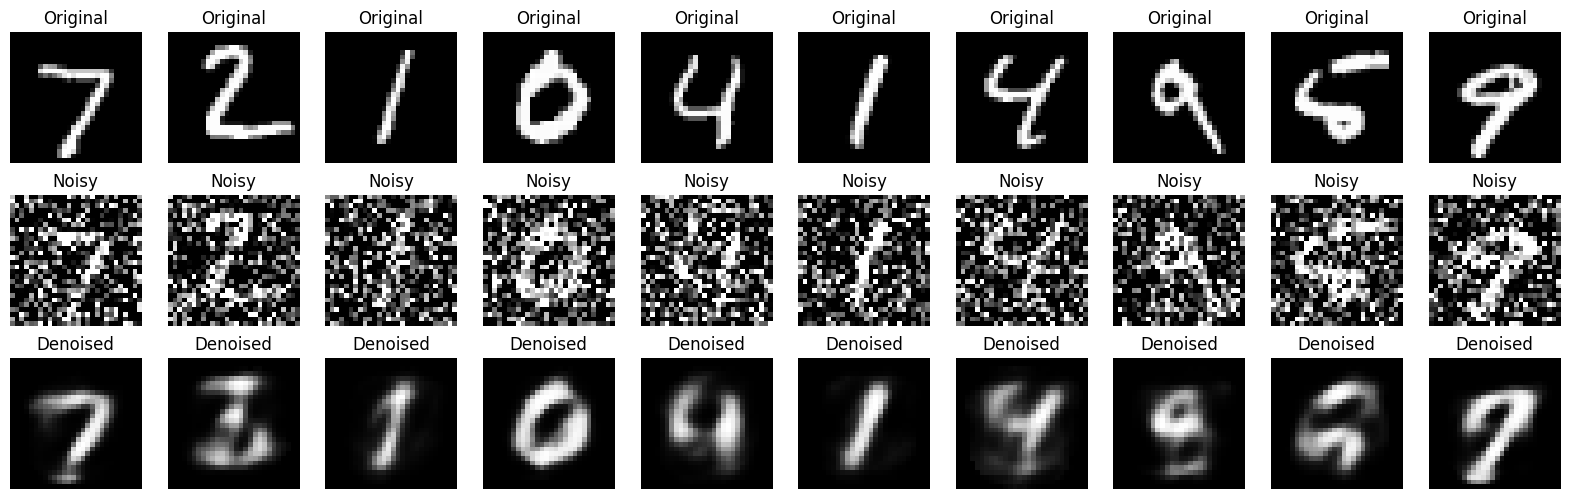

In [20]:
test(model_1)

## Transpose CNN Autoencoder

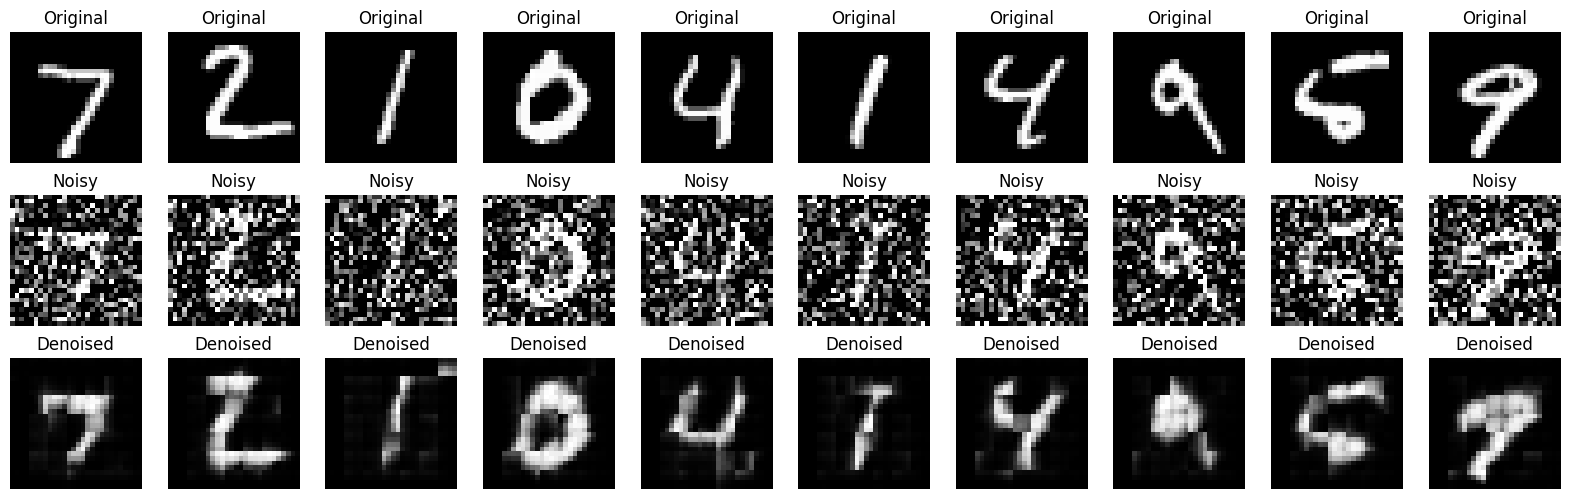

In [21]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

/var/folders/98/g26wy2d54m727kzzxfvlss340000gn/T/ipykernel_4319/219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/var/folders/98/g26wy2d54m727kzzxfvlss340000gn/T/ipykernel_4319/219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')


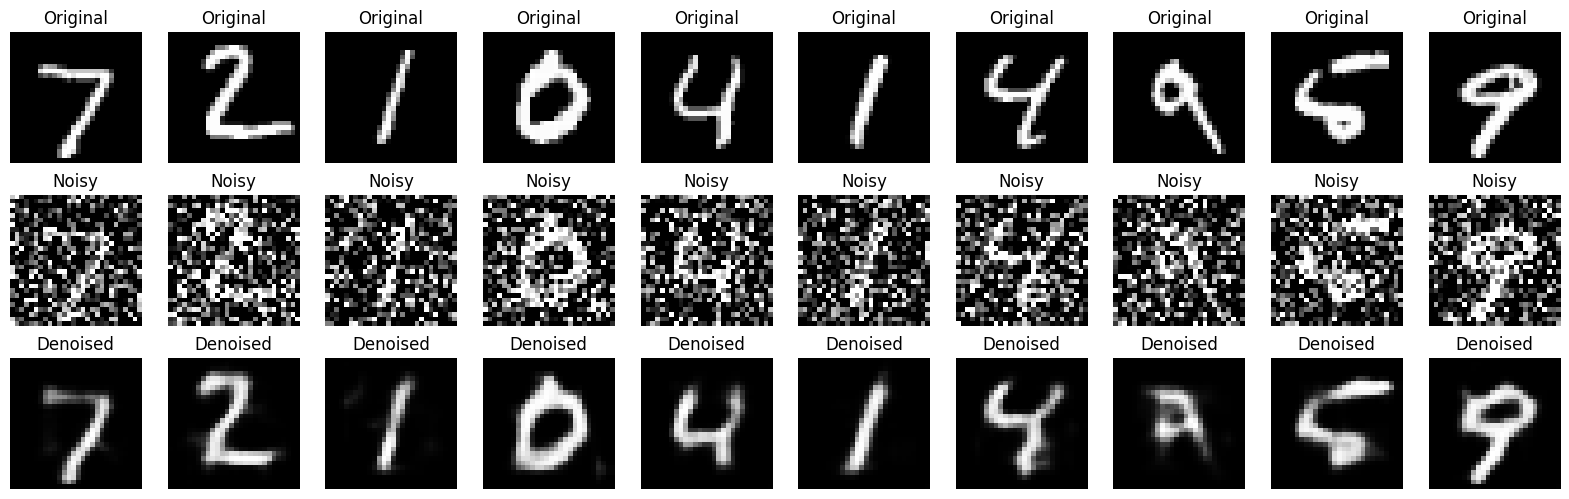

In [22]:
test(model_3,'conv')